
## Worksheet 1 — Image Compression and Decompression using PCA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Update these paths to where your images are in Google Drive
colored_path = '/content/drive/MyDrive/AI and Machine Learning/bell.jpg'
gray_path    = '/content/drive/MyDrive/AI and Machine Learning/bell.jpg'

## Exercise 1

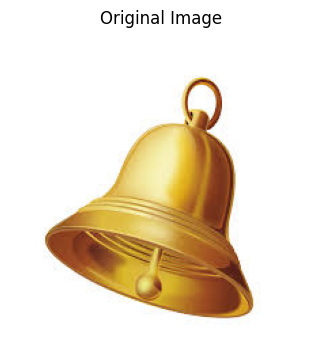

In [3]:
# Task 1 — Read and display the image
image_colored = Image.open(colored_path).convert('RGB')
image_array   = np.array(image_colored)

plt.figure(figsize=(5, 4))
plt.imshow(image_array)
plt.title('Original Image')
plt.axis('off')
plt.show()

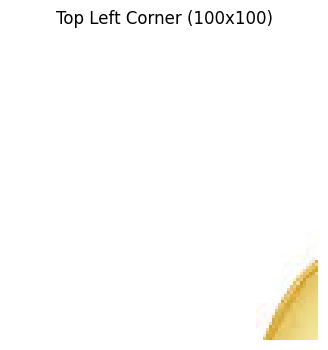

In [4]:
# Task 2 — Display only the top-left corner (100x100 pixels)
top_left = image_array[:100, :100, :]

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title('Top Left Corner (100x100)')
plt.axis('off')
plt.show()

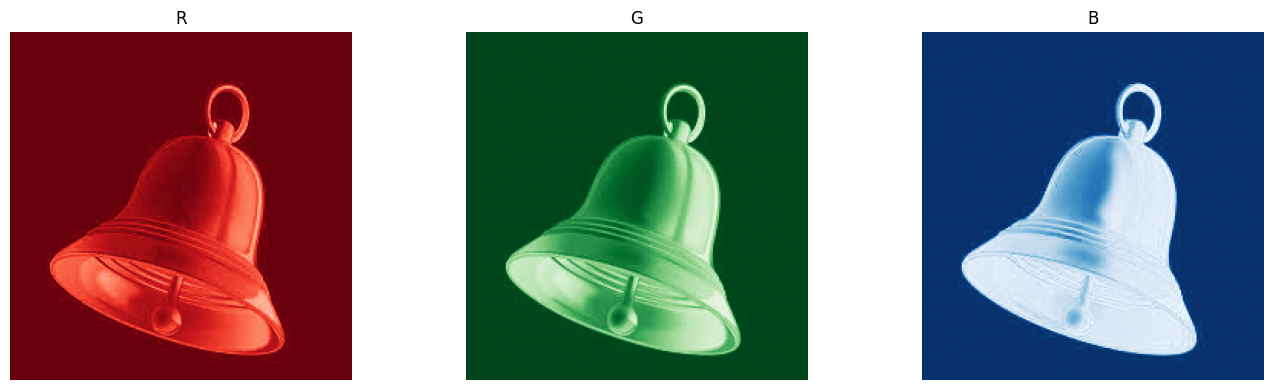

In [5]:
# Task 3 — Show the three colour channels (R, G, B) using NumPy
red_channel   = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel  = image_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(red_channel,   cmap='Reds');   axes[0].set_title('R'); axes[0].axis('off')
axes[1].imshow(green_channel, cmap='Greens'); axes[1].set_title('G'); axes[1].axis('off')
axes[2].imshow(blue_channel,  cmap='Blues');  axes[2].set_title('B'); axes[2].axis('off')
plt.tight_layout()
plt.show()

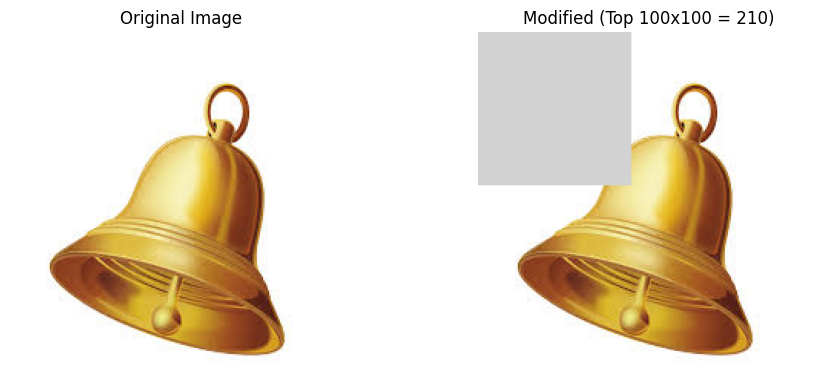

In [6]:
# Task 4 — Modify top 100x100 pixels to value 210
modified = image_array.copy()
modified[:100, :100, :] = 210

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_array); axes[0].set_title('Original Image');             axes[0].axis('off')
axes[1].imshow(modified);    axes[1].set_title('Modified (Top 100x100 = 210)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

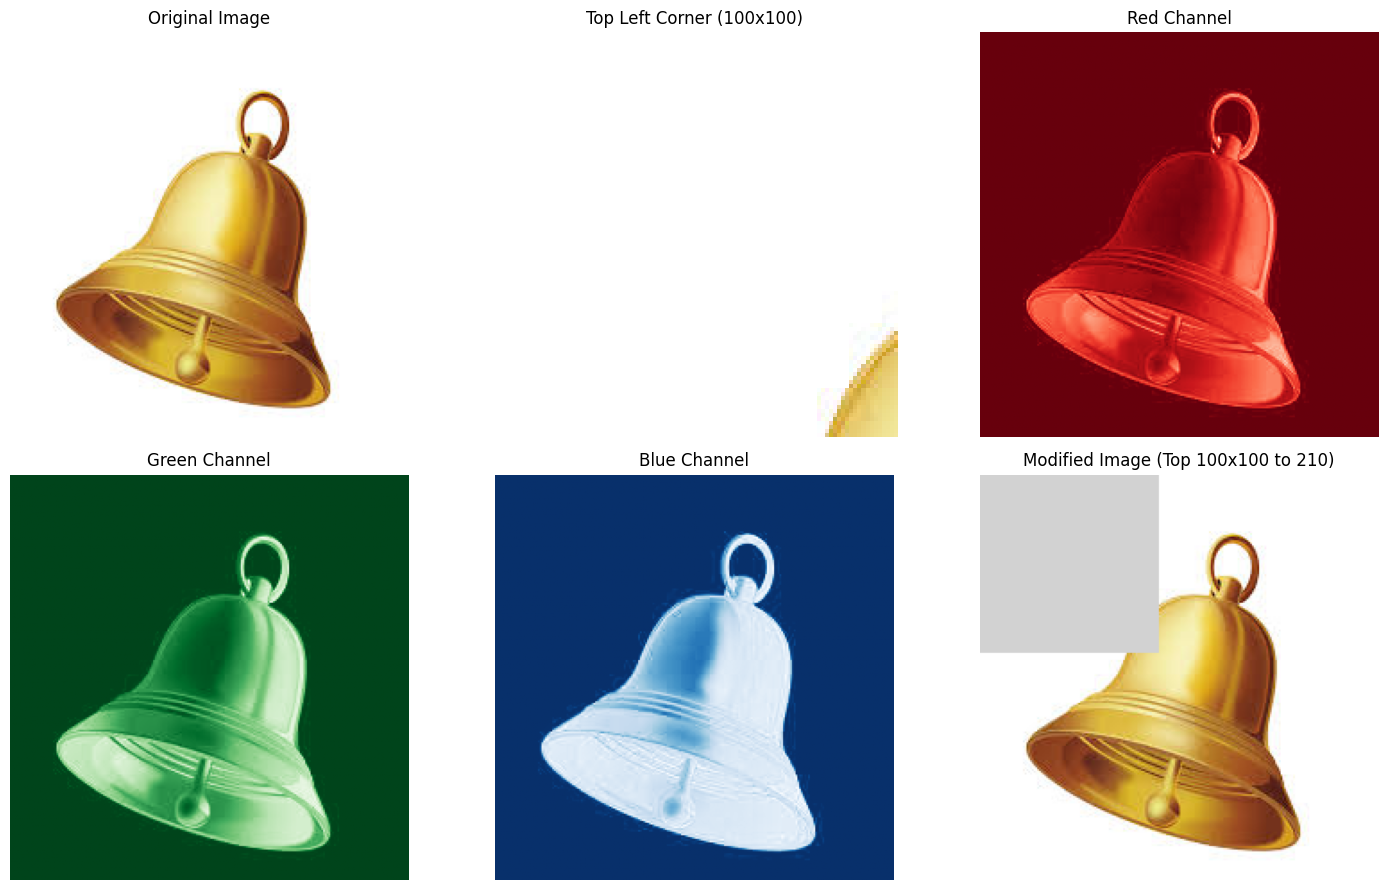

In [7]:
# Summary plot — Exercise 1
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0][0].imshow(image_array);                  axes[0][0].set_title('Original Image');             axes[0][0].axis('off')
axes[0][1].imshow(top_left);                     axes[0][1].set_title('Top Left Corner (100x100)'); axes[0][1].axis('off')
axes[0][2].imshow(red_channel,   cmap='Reds');   axes[0][2].set_title('Red Channel');               axes[0][2].axis('off')
axes[1][0].imshow(green_channel, cmap='Greens'); axes[1][0].set_title('Green Channel');             axes[1][0].axis('off')
axes[1][1].imshow(blue_channel,  cmap='Blues');  axes[1][1].set_title('Blue Channel');              axes[1][1].axis('off')
axes[1][2].imshow(modified);                     axes[1][2].set_title('Modified Image (Top 100x100 to 210)'); axes[1][2].axis('off')

plt.tight_layout()
plt.show()

## Exercise 2

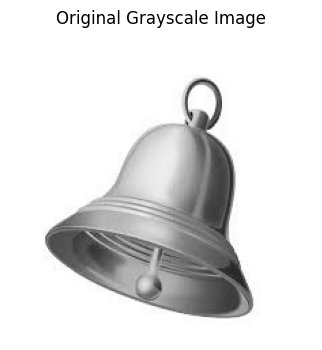

Shape: (227, 223)
Pixel range: min = 6  max = 255


In [8]:
# Task 1 — Load and display a grayscale image
image_gray_pil = Image.open(gray_path).convert('L')
image_gray     = np.array(image_gray_pil)

plt.figure(figsize=(5, 4))
plt.imshow(image_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

print('Shape:', image_gray.shape)
print('Pixel range: min =', image_gray.min(), ' max =', image_gray.max())

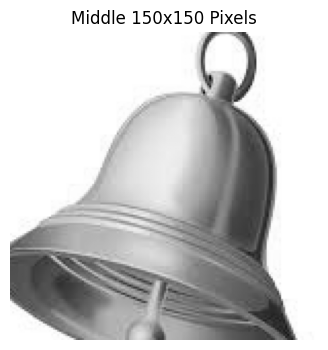

In [9]:
# Task 2 — Extract and display the middle section (150x150 pixels)
h, w   = image_gray.shape
cr, cc = h // 2, w // 2
middle = image_gray[cr - 75 : cr + 75, cc - 75 : cc + 75]

plt.figure(figsize=(4, 4))
plt.imshow(middle, cmap='gray')
plt.title('Middle 150x150 Pixels')
plt.axis('off')
plt.show()

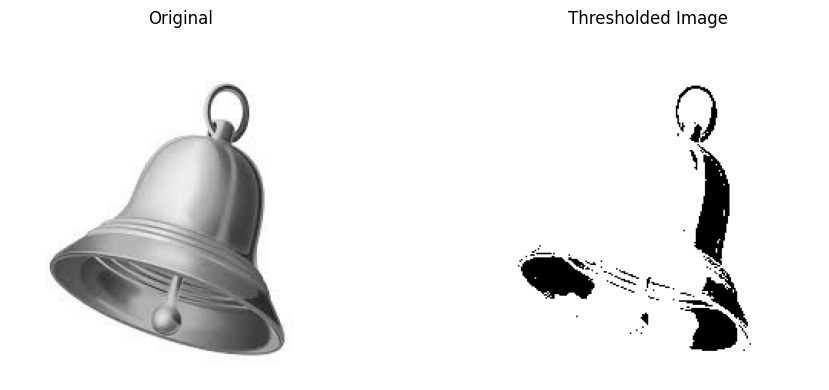

In [10]:
# Task 3 — Apply threshold: pixels < 100 -> 0, else -> 255
thresholded = np.where(image_gray < 100, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_gray,  cmap='gray'); axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(thresholded, cmap='gray'); axes[1].set_title('Thresholded Image'); axes[1].axis('off')
plt.tight_layout()
plt.show()

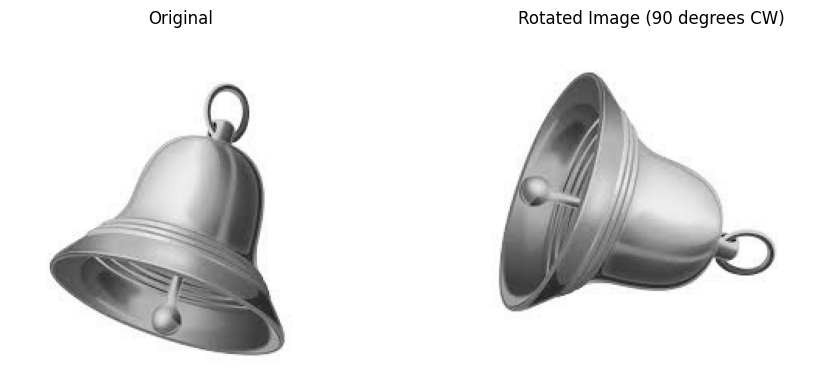

In [11]:
# Task 4 — Rotate 90 degrees clockwise
rotated_pil = image_gray_pil.rotate(-90, expand=True)
rotated     = np.array(rotated_pil)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_gray, cmap='gray'); axes[0].set_title('Original');                        axes[0].axis('off')
axes[1].imshow(rotated,    cmap='gray'); axes[1].set_title('Rotated Image (90 degrees CW)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

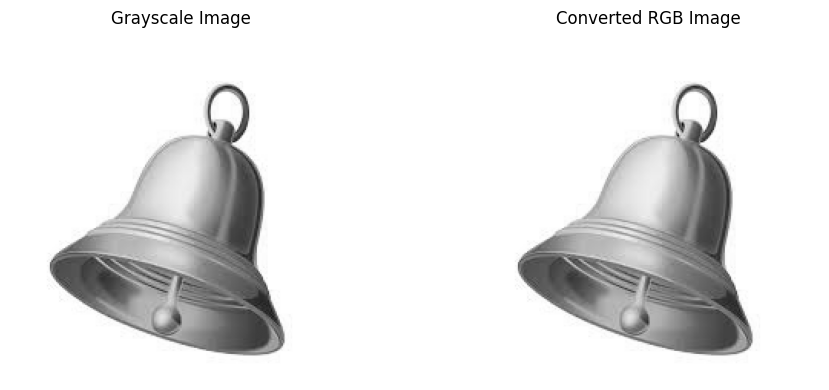

Grayscale shape: (227, 223)
RGB shape      : (227, 223, 3)


In [12]:
# Task 5 — Convert grayscale to RGB
rgb_from_gray = np.stack([image_gray, image_gray, image_gray], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_gray,    cmap='gray'); axes[0].set_title('Grayscale Image');    axes[0].axis('off')
axes[1].imshow(rgb_from_gray);              axes[1].set_title('Converted RGB Image'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Grayscale shape:', image_gray.shape)
print('RGB shape      :', rgb_from_gray.shape)

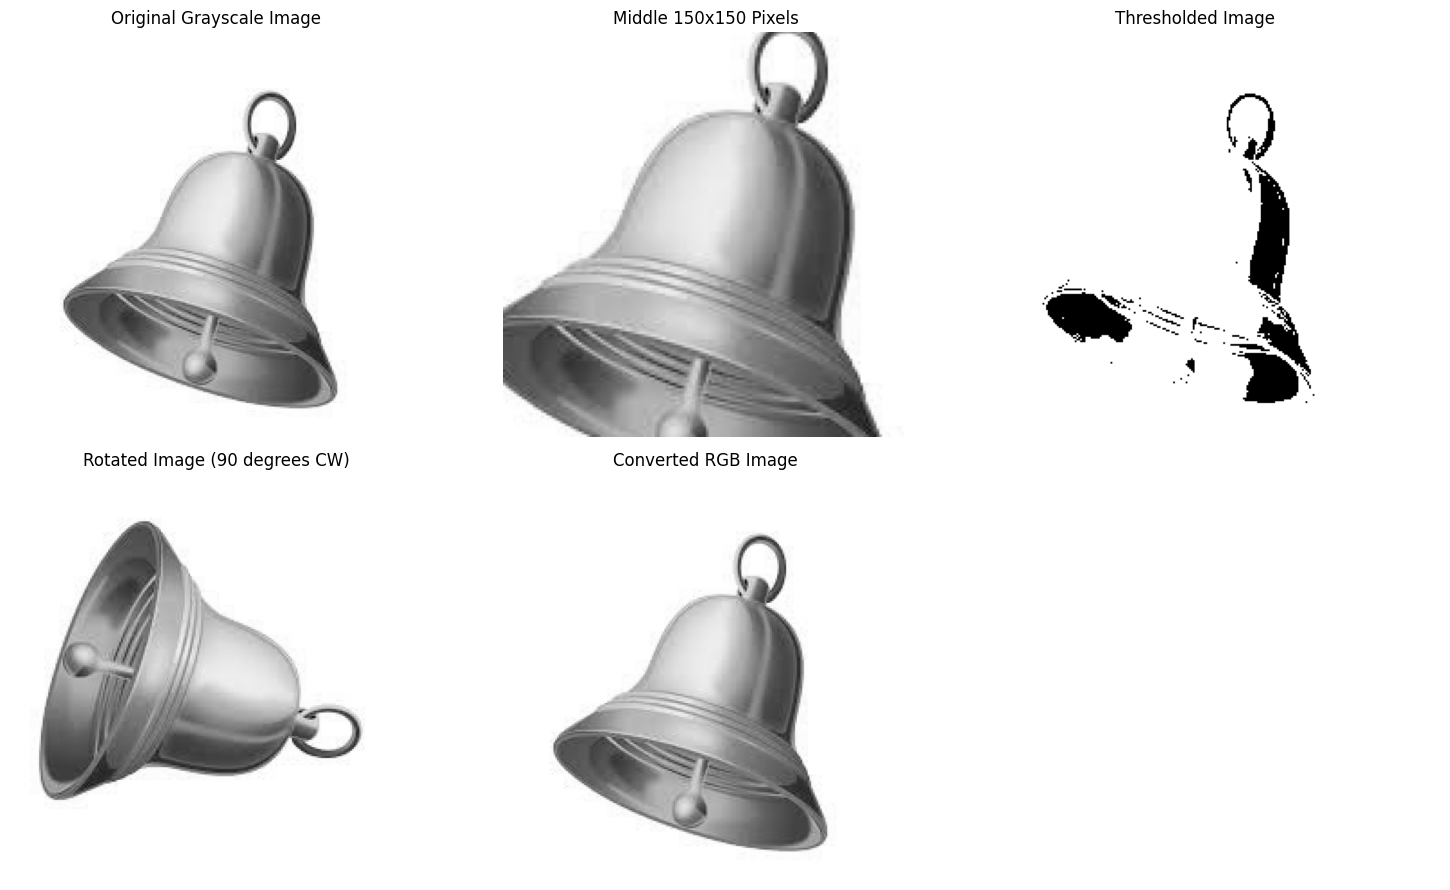

In [13]:
# Summary plot — Exercise 2
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0][0].imshow(image_gray,    cmap='gray'); axes[0][0].set_title('Original Grayscale Image');      axes[0][0].axis('off')
axes[0][1].imshow(middle,        cmap='gray'); axes[0][1].set_title('Middle 150x150 Pixels');         axes[0][1].axis('off')
axes[0][2].imshow(thresholded,   cmap='gray'); axes[0][2].set_title('Thresholded Image');             axes[0][2].axis('off')
axes[1][0].imshow(rotated,       cmap='gray'); axes[1][0].set_title('Rotated Image (90 degrees CW)'); axes[1][0].axis('off')
axes[1][1].imshow(rgb_from_gray);              axes[1][1].set_title('Converted RGB Image');           axes[1][1].axis('off')
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

## Exercise 3 — PCA Image Compression from Scratch

In [14]:
# Load and prepare data
pca_image = np.array(Image.open(gray_path).convert('L'), dtype=np.float64)
height, width = pca_image.shape
data = pca_image

print('Image shape:', pca_image.shape)

Image shape: (227, 223)


In [15]:
# Standardise — subtract mean
mean          = np.mean(data, axis=0)
centered_data = data - mean

print('Mean shape        :', mean.shape)
print('Centered data shape:', centered_data.shape)

Mean shape        : (223,)
Centered data shape: (227, 223)


In [16]:
# Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

print('Covariance matrix shape:', cov_matrix.shape)

Covariance matrix shape: (223, 223)


In [17]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues    = eigenvalues[sorted_indices]
eigenvectors   = eigenvectors[:, sorted_indices]

print('Eigenvalues shape :', eigenvalues.shape)
print('Eigenvectors shape:', eigenvectors.shape)

Eigenvalues shape : (223,)
Eigenvectors shape: (223, 223)


80% variance explained by 3 components
90% variance explained by 8 components
95% variance explained by 14 components
99% variance explained by 39 components


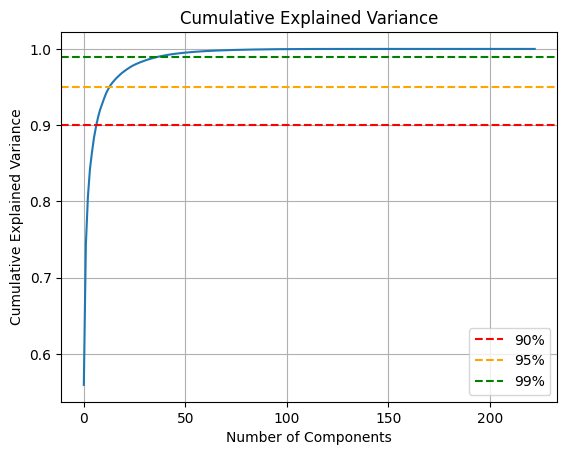

In [18]:
# Cumulative explained variance plot
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

for t in [0.80, 0.90, 0.95, 0.99]:
    n = np.searchsorted(cumulative_variance, t) + 1
    print(f'{int(t*100)}% variance explained by {n} components')

plt.plot(cumulative_variance)
plt.axhline(y=0.90, color='red',    linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.axhline(y=0.99, color='green',  linestyle='--', label='99%')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

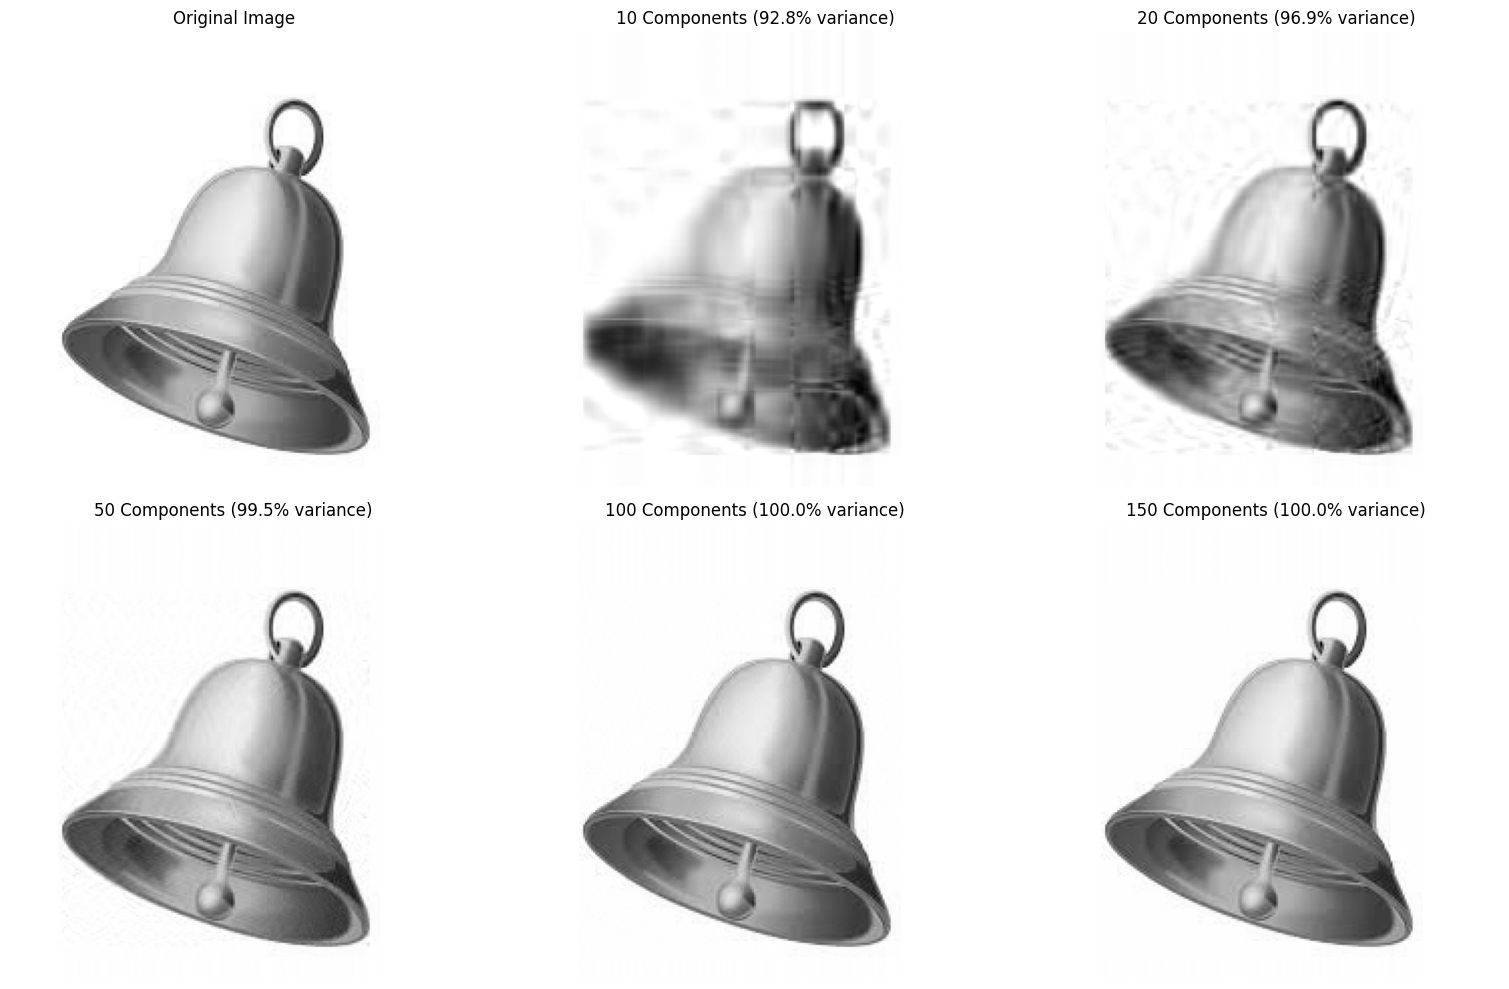

In [19]:
# Reconstruct image with different values of k and compare
def reconstruct(centered_data, eigenvectors, mean, k):
    components    = eigenvectors[:, :k]
    compressed    = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean
    return np.clip(reconstructed, 0, 255).astype(np.uint8)

k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

axes[0].imshow(pca_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, k in enumerate(k_values):
    recon = reconstruct(centered_data, eigenvectors, mean, k)
    var   = cumulative_variance[k - 1] * 100
    axes[i + 1].imshow(recon, cmap='gray')
    axes[i + 1].set_title(f'{k} Components ({var:.1f}% variance)')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()